# 분류분석 평가 지표
- 분류분석을 평가하기 위한 지표들은 머신러닝 모델이 얼마나 잘 작동하는지를 판단
- 주요 평가 지표
    1. 정확도 (Accuracy)
        - 모든 예측 중 올바르게 예측된 비율
        - (TP+TN)/(TP+TN+FP+FN)
    2. 정밀도 (Precision)
        - 양성으로 예측된 경우 중 실제로 양성인 경우의 비율
        - TP/(TP+FP)
    3. 재현율 (Recall) 또는 민감도 (Sensitivity)
        - 실제 양성 중에서 양성으로 예측된 비율
        - TP/(TP+FN)
    4. F1 점수 (F1 Score)
        - 정밀도와 재현율의 조화 평균
        - 2×(Precision×Recall)/(Precision+Recall)

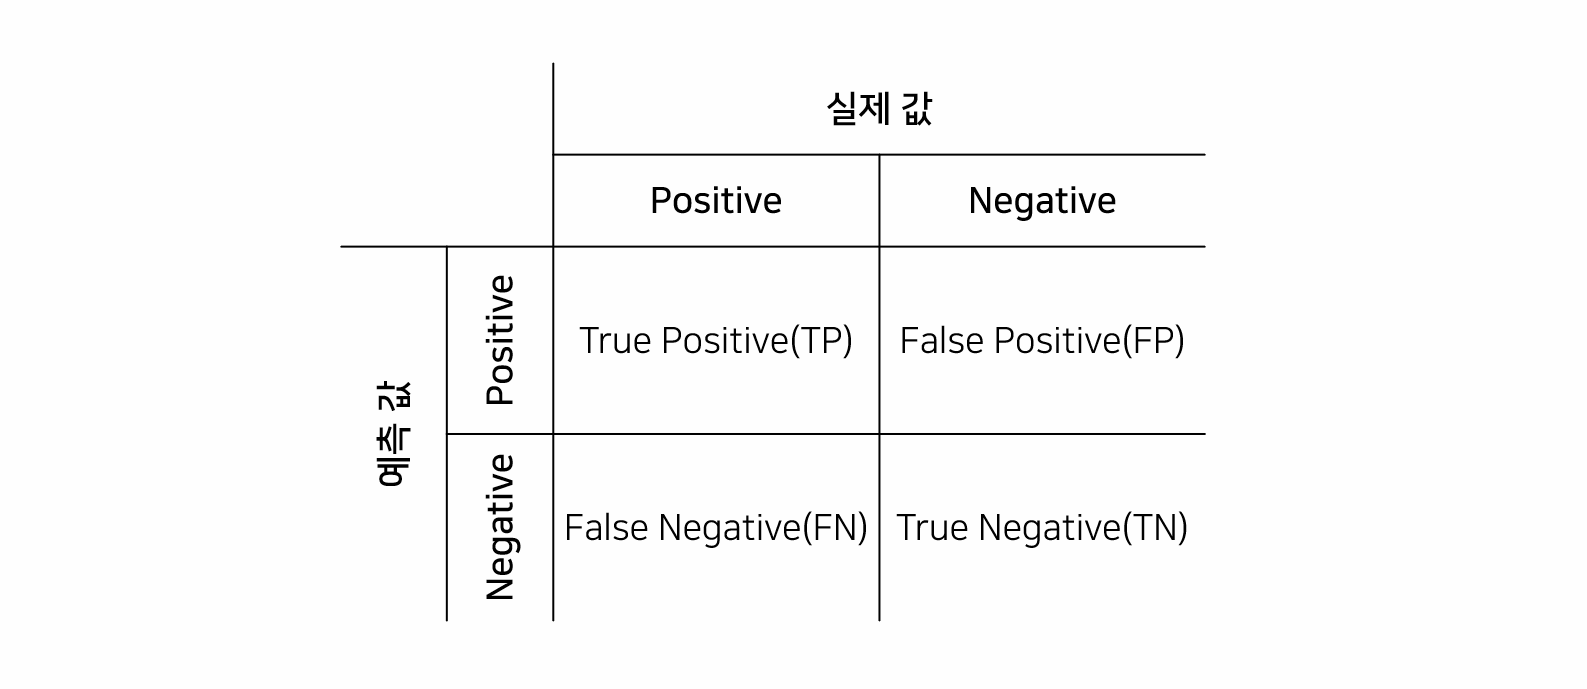

<br/>
<br/>

In [3]:
# (코드 실행)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [4]:
# (코드 실행) 데이터 생성
data = {
    'Temperature': [22, 28, 24, 30, 18, 20, 25, 27, 21, 26, 23, 29, 19, 25, 24, 31, 17, 28, 22, 19],  # 기온 (도씨)
    'RainProb': [80, 20, 60, 10, 90, 70, 30, 20, 75, 40, 80, 15, 85, 55, 45, 95, 5, 60, 80, 10],      # 강수 확률 (%)
    'Umbrella': [1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0]                          # 우산 필요 (1: 필요, 0: 불필요)
}

# DataFrame 생성
df = pd.DataFrame(data)
df

,Temperature,RainProb,Umbrella
0,22,80,1
1,28,20,0
2,24,60,1
3,30,10,0
4,18,90,1
5,20,70,1
6,25,30,0
7,27,20,0
8,21,75,1
9,26,40,0


In [5]:
# X, y 분리
X = df.drop('Umbrella', axis=1)
y = df['Umbrella']
X

,Temperature,RainProb
0,22,80
1,28,20
2,24,60
3,30,10
4,18,90
5,20,70
6,25,30
7,27,20
8,21,75
9,26,40


In [6]:
# KNN 모델 생성 및 학습
# n_neighbors=3
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

KNeighborsClassifier(n_neighbors=3)

In [7]:
# 모델 평가
model.score(X, y)

0.9

In [8]:
# 전체 데이터에 대한 예측
pred = model.predict(X)
pred

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0])

In [9]:
# 데이터프레임에 예측 결과 추가
df['Predict'] = pred
df

,Temperature,RainProb,Umbrella,Predict
0,22,80,1,1
1,28,20,0,0
2,24,60,1,1
3,30,10,0,0
4,18,90,1,1
5,20,70,1,1
6,25,30,0,0
7,27,20,0,0
8,21,75,1,1
9,26,40,0,0


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 성능 지표 계산
accuracy = accuracy_score(y, pred)
precision = precision_score(y, pred)
recall = recall_score(y, pred)
f1 = f1_score(y, pred)

# 결과 출력
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Accuracy: 0.90
Precision: 0.82
Recall: 1.00
F1 Score: 0.90
